In [19]:
!pip install pandas numpy matplotlib seaborn scikit-learn


PART 1

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn.svm 
from sklearn.svm import SVC

In [4]:
df = pd.read_csv("C:/Users/Ahmed Wael/Downloads/diabetes.csv")


In [5]:
#1.1 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_43040\925151660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette=['red', 'blue'])


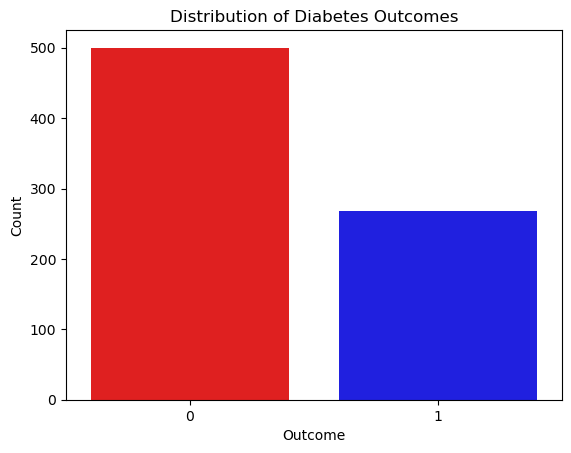

In [7]:
#1.2
sns.countplot(data=df, x='Outcome', palette=['red', 'blue'])
plt.title('Distribution of Diabetes Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.tight_layout
plt.show()

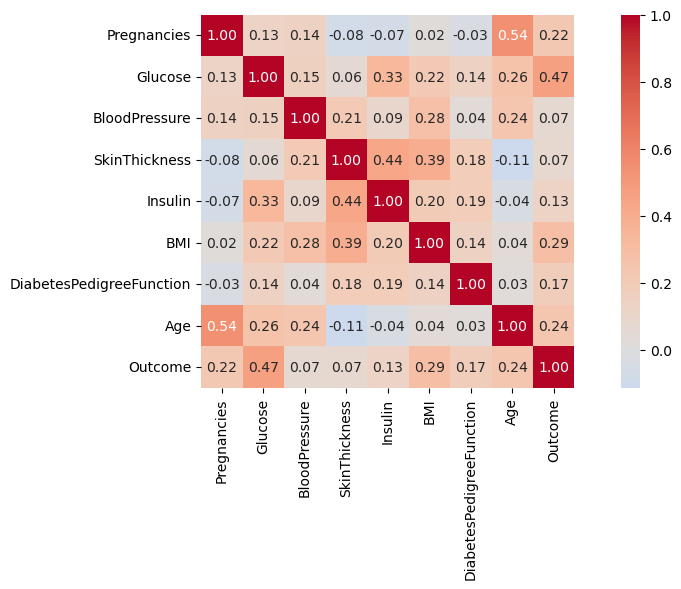

In [8]:
# 1.3
correlation_heatmap = df.corr()
plt.figure(figsize=(10,6))

sns.heatmap(correlation_heatmap, annot=True,square=True, fmt='.2f', cmap='coolwarm', center=0)

plt.tight_layout()
plt.show()

In [9]:
# 1.4
print(df.isnull().sum())
# no missing
df.describe()
# some features have 0 is their value which is impossible like BMI, Blood Pressure, Glucose, Insulin and Skin Thickness

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


PART 2

In [10]:
#2.1
#BMI, Blood Pressure, Glucose, Insulin and Skin Thickness


#2.2
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].median())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].median())


# 2.3: Median is a good choice because it is the middle data so the value is not an outlier 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


PART 4

In [21]:
from sklearn.metrics import classification_report
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
print(f'Accuracy is {round(model_linear.score(X_test, y_test),3)}')

y_pred_linear = model_linear.predict(X_test)

print(classification_report(y_test, y_pred_linear))

Accuracy is 0.708
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [12]:
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)
print(f'Accuracy is {round(model_rbf.score(X_test, y_test),3)}')

y_pred_rbf = model_rbf.predict(X_test)

print(classification_report(y_test, y_pred_rbf))

Accuracy is 0.701
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       100
           1       0.61      0.41      0.49        54

    accuracy                           0.70       154
   macro avg       0.67      0.63      0.64       154
weighted avg       0.69      0.70      0.68       154



In [13]:
model_poly = SVC(kernel='poly')
model_poly.fit(X_train, y_train)
print(f'Accuracy is {round(model_poly.score(X_test, y_test),3)}')

y_pred_poly = model_poly.predict(X_test)

print(classification_report(y_test, y_pred_poly))

# we can see the polynomial kernel was the most accurate out of the 3 and the rbf was the least accurate

Accuracy is 0.747
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       100
           1       0.70      0.48      0.57        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154



PART 5

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.svm import SVC 

model = SVC()

parameters = {
    'C': [0.1, 1,2,3,4,5,6],
    'gamma': [0.1,1,2,3,4,5,6],
    'kernel': ['linear', 'rbf']

}

grid = GridSearchCV(model, parameters)
grid


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [33]:
grid.fit(X_train_scaled, y_train)


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [34]:
from sklearn.metrics import accuracy_score

grid.best_params_

best_model = SVC(C=1, gamma=0.1, kernel='linear')

best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_best))
print(accuracy_score(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

0.7077922077922078


PART 6

In [ ]:
print(f'Number of support vectors: {len(best_model.support_)}')
len(best_model.n_support_)

training_size = len(X_train_scaled)
print(training_size)

ratio_svc = len(best_model.support_) / training_size
round(ratio_svc,3)

# the points are important because its the only points that matter

Number of support vectors: 308
614


0.502

PART 7

In [58]:
df_noisy = df.copy()

np.random.seed(42)
df_noisy['Glucose'] = df_noisy['Glucose'] + np.random.uniform(-10,10, len(df))

X_noisy = df_noisy.drop('Outcome', axis=1)
X_noisy_scaled = scaler.fit_transform(X_noisy)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy_scaled, y, test_size=0.2, random_state=42, stratify=y)

model_noisy = SVC(C=1, gamma=0.1, kernel='linear')
model_noisy.fit(X_train_n, y_train_n)

y_pred_n = model_noisy.predict(X_test_n)


print(f'Accuracy score is {round(model_noisy.score(X_test_n, y_test_n),3)}')
print(classification_report(y_test_n, y_pred_n))

Accuracy score is 0.714
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.61      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

